<a href="https://colab.research.google.com/github/sri-vyshnavi-jakkam/Project1/blob/main/DR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras import layers, models

In [30]:
dataset_path = "/content/drive/MyDrive/Retinopathy"
print(os.listdir(dataset_path))

['export.pkl', 'train.csv', 'Proliferate_DR', 'Severe', 'No_DR', 'Moderate', 'Mild']


In [31]:
data = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    image_size=(224,224),
    batch_size=32,
    label_mode="int",
    shuffle=True
)

Found 3662 files belonging to 5 classes.


In [34]:
train_size = int(len(data)*0.8)

train_data = data.take(train_size)
val_data = data.skip(train_size)

In [35]:
from tensorflow.keras.applications.efficientnet import preprocess_input

def preprocess(x, y):

    x = tf.cast(x, tf.float32)

    x = preprocess_input(x)

    x.set_shape((None,224,224,3))

    return x, y


train_data = train_data.map(preprocess)
val_data = val_data.map(preprocess)

In [36]:
AUTOTUNE = tf.data.AUTOTUNE

train_data = train_data.prefetch(buffer_size=AUTOTUNE)
val_data = val_data.prefetch(buffer_size=AUTOTUNE)

In [37]:
from tensorflow.keras.applications import EfficientNetB0

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

In [38]:
for layer in base_model.layers[:-20]:
    layer.trainable = False

In [39]:
# 10. MODEL ARCHITECTURE
# ==============================

x = base_model.output

# Global pooling converts feature maps into vector
x = layers.GlobalAveragePooling2D()(x)

# Dense feature learning layer
x = layers.Dense(512, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)

In [41]:
# 11. ATTENTION MECHANISM
# ==============================
# Sigmoid gating lets each neuron independently
# control its importance

attention = layers.Dense(512, activation='sigmoid')(x)

# Multiply attention weights with features
x = layers.multiply([x, attention])

In [42]:
# 12. CLASSIFIER LAYERS
# ==============================

x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)

# Final output layer for 5 DR classes
outputs = layers.Dense(5, activation='softmax')(x)


In [43]:
# 13. BUILD MODEL
# ==============================

model = models.Model(inputs=base_model.input, outputs=outputs)
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 5,365,416 (20.47 MB)

 Trainable params: 2,665,781 (10.17 MB)

 Non-trainable params: 2,699,635 (10.30 MB)

In [46]:
# 14. COMPILE MODEL
# ==============================

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [48]:
# 15. TRAIN MODEL
# ==============================

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)

Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 29s 314ms/step - accuracy: 0.8546 - loss: 0.3936 - val_accuracy: 0.7716 - val_loss: 0.6045
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 26s 282ms/step - accuracy: 0.8832 - loss: 0.3396 - val_accuracy: 0.7911 - val_loss: 0.5557
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 26s 287ms/step - accuracy: 0.8774 - loss: 0.3350 - val_accuracy: 0.8398 - val_loss: 0.5610
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 27s 291ms/step - accuracy: 0.8913 - loss: 0.2999 - val_accuracy: 0.8245 - val_loss: 0.7129
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 26s 287ms/step - accuracy: 0.8940 - loss: 0.2897 - val_accuracy: 0.8301 - val_loss: 0.5738
Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 26s 280ms/step - accuracy: 0.9018 - loss: 0.2823 - val_accuracy: 0.7939 - val_loss: 0.6916
Epoch 7/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 26s 279ms/step - accuracy: 0.9117 - loss: 0.2465 - val_accuracy: 0.8384 - val_loss: 0.5974
Epoch 8/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 26s 285ms/step - accuracy: 0.9171 - loss: 0.2381 - val_accu

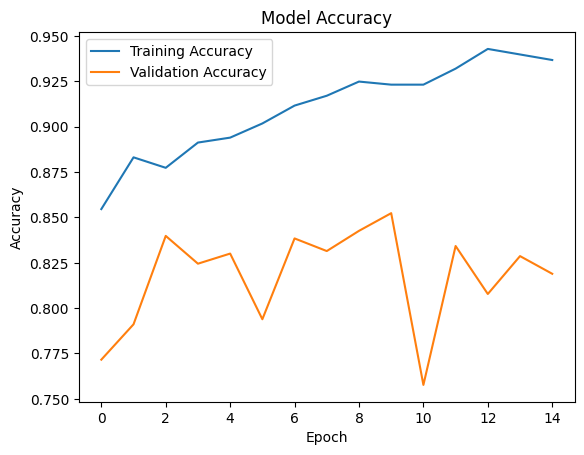

In [52]:
# 16. ACCURACY GRAPH
# =====================================

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

In [56]:
# 17. MODEL EVALUATION
# ==============================

loss, accuracy = model.evaluate(val_data)

print("Validation Accuracy:",accuracy)

23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 121ms/step - accuracy: 0.8217 - loss: 0.7052
Validation Accuracy: 0.8217270374298096


1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


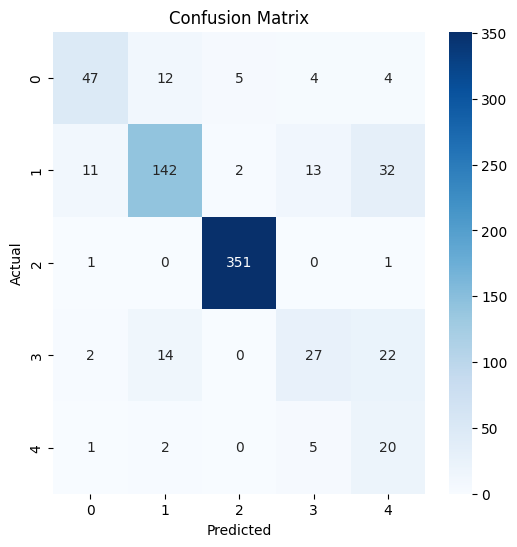

In [57]:
# 18. CONFUSION MATRIX
# ==============================

y_true = []
y_pred = []

for images, labels in val_data:

    preds = model.predict(images)

    preds = np.argmax(preds,axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)


cm = confusion_matrix(y_true,y_pred)


plt.figure(figsize=(6,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [62]:
# 20. CLASSIFICATION REPORT

print(classification_report(y_true,y_pred))


              precision    recall  f1-score   support

           0       0.76      0.65      0.70        72
           1       0.84      0.71      0.77       200
           2       0.98      0.99      0.99       353
           3       0.55      0.42      0.47        65
           4       0.25      0.71      0.37        28

    accuracy                           0.82       718
   macro avg       0.68      0.70      0.66       718
weighted avg       0.85      0.82      0.83       718



In [63]:
# 21. SAVE MODEL

model.save("DR_detection_model.keras")